## *2026 Spring DSAA 2011 Machine Learning*
## Lab Note 01 (Solutions)
*Jing Xu, Changkai Mai, Liangwei Wang, Zixin Zhong* \
*Hong Kong University of Science and Technology (Guangzhou)*

**Important note**: make sure Python, Anaconda and Jupyter lab can be used in your computer. Refer to the note of lab 0 regarding the environment equipment.


**Question 1.** What is the difference between online learning and offline learning?

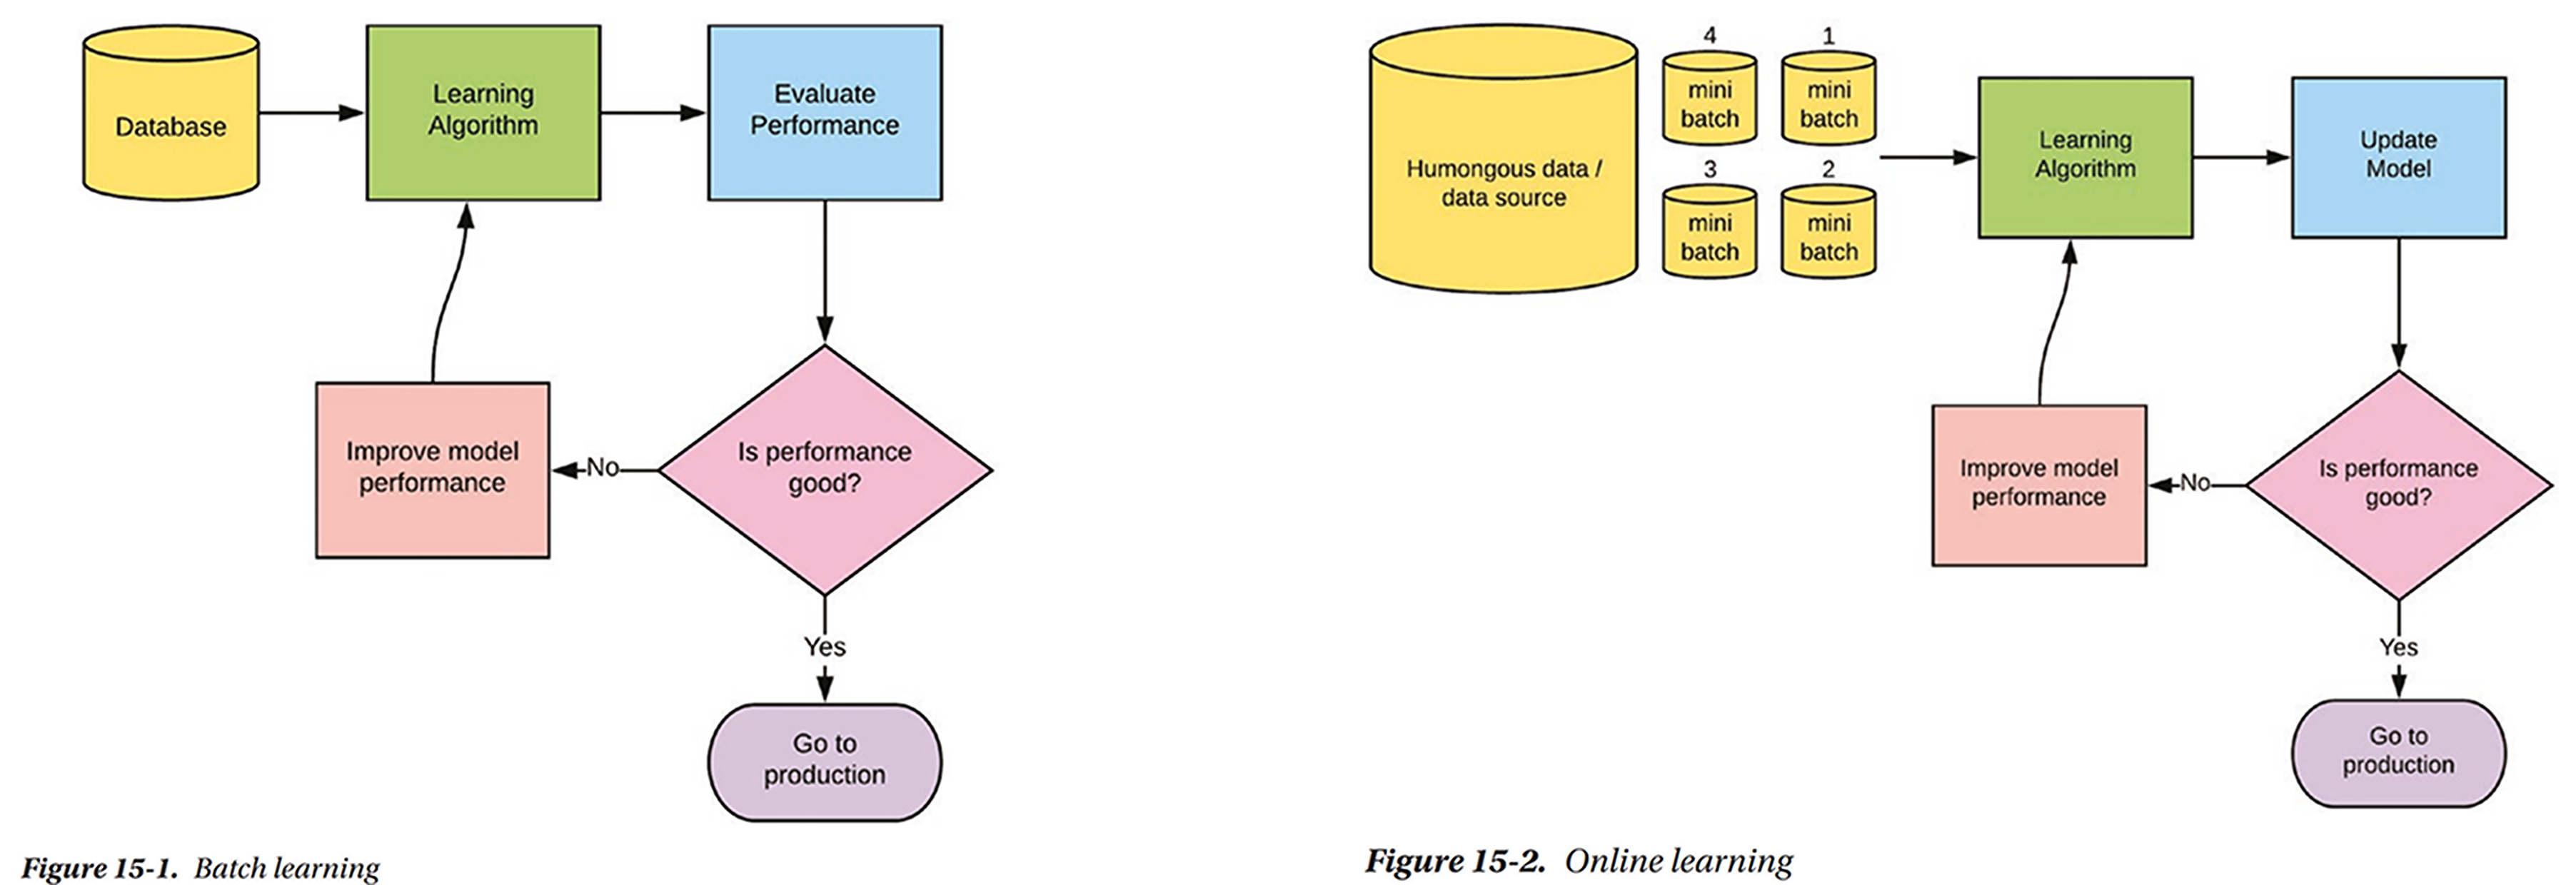

| Characteristic | Batch (Offline) Learning | Online Learning |
|----------------|-------------------------|-----------------|
| Data Processing | Processes complete dataset at once; **"Data at rest"**. Requires retraining from scratch when new data arrives. | Processes data in streams (individual samples or mini-batches); **"Data in motion"**. Model updates continuously. |
| Resource Management | Higher storage and computational requirements as it needs entire dataset, but processing is done once until next update. | Lower immediate resource needs but requires continuous processing capability. Efficient memory usage as it only needs current data. |
| Use Cases & Applications | Traditional ML tasks with stable datasets (e.g., image classification, text categorization). Suitable when real-time updates aren't critical. | Real-time applications with continuous data streams (e.g., stock market prediction, fraud detection, recommendation systems). |
| Advantages & Limitations | + More stable model performance<br>+ Can optimize over entire dataset<br>- Expensive to update<br>- Not suitable for real-time applications | + Adapts to changing patterns<br>+ Real-time learning capability<br>+ Memory efficient<br>- May be less stable<br>- Sensitive to noise |
| Learning Process | Clear training-testing-deployment cycle. Learning ends after model deployment until next retraining. | Continuous prediction-learning-update cycle. Model evolves with new data. |

---

**Question 2.** Show that if $f:\mathbb{R}^d\to\mathbb{R}$ is a linear function, then $f$ must pass through the origin, i.e., $f(\mathbf{0})=0$ where $\mathbf{0}\in\mathbb{R}^d$ is the zero vector with $d$ dimensions.

**Solution:**
1. **Definition of a Linear Function**:  
   A function $f:\mathbb{R}^d\to\mathbb{R}$  is linear if it satisfies:  
   - **Additivity**:  f(x + y) = f(x) + f(y)  for all  x, y $\in$ $\mathbb{R}^d$,  
   - **Homogeneity**:  f(cx) = c f(x)  for all  x $\in$ $\mathbb{R}^d$  and  c $\in$ $\mathbb{R}$ .  

2. **Evaluate $f(\mathbf{0})$**:  
   Let  0 $\in$ $\mathbb{R}^d$  be the zero vector (i.e., \( 0 = (0, 0, $\dots$, 0) \)).  

   Using the additivity property, we have:  
   $$
   f(0 + 0) = f(0) + f(0).
   $$  
   Simplifying:  
   $$
   f(0) = f(0) + f(0).
   $$

3. **Simplify**:  
   Subtract $f(\mathbf{0})$ from both sides of the equation:  
   $$
   f(0) - f(0) = f(0).
   $$ 
   This implies:  
   $$
   f(0) = 0.
   $$

**Question 3.** Is a linear function affine? Is an affine function linear?

**Solution:**

**Definition of a Linear Function:**

A function $f : \mathbb{R}^n \to \mathbb{R}^m$ is called **linear** if it satisfies the following two properties for all $x, y \in \mathbb{R}^n$ and $c \in \mathbb{R}$:

1. **Additivity**: $f(x + y) = f(x) + f(y)$.
2. **Homogeneity**: $f(c x) = c f(x)$.

In other words, a linear function can be written in the form:
$$
f(x) = A x,
$$
where $A$ is an $m \times n$ matrix, and $x \in \mathbb{R}^n$.

---

**Definition of an Affine Function:**

A function $g : \mathbb{R}^n \to \mathbb{R}^m$ is called **affine** if it can be written in the form:
$$
g(x) = A x + b,
$$
where $A$ is an $m \times n$ matrix, $x \in \mathbb{R}^n$, and $b \in \mathbb{R}^m$ is a constant vector.

---

**Relation Between Linear and Affine Functions:**

1. **Is a linear function affine?**
   - Yes, a linear function is a special case of an affine function where the constant vector $b = 0$.  
     That is, if $g(x) = A x + b$ and $b = 0$, then $g(x) = A x$, which is a linear function.

2. **Is an affine function linear?**
   - No, an affine function is not necessarily linear because of the presence of the constant vector $b$.  
     The constant vector $b$ breaks the homogeneity property of linearity. For example:
     - If $g(x) = A x + b$, then $g(c x) = A (c x) + b = c A x + b \neq c g(x)$ unless $b = 0$.

---

**Conclusion:**

- A linear function is always affine.  
- An affine function is not always linear unless the constant vector $b = 0$.

**Question 4.** Let $A\in\mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$. Define the function:
$$
f(x) = \|Ax - b\|^2_2 = (Ax - b)^\top(Ax - b), \quad x \in \mathbb{R}^n
$$

1. Compute the gradient $\nabla_xf(x)$.
2. Compute the Hessian matrix $\nabla^2_xf(x)$
3. (Optional) Validate your answer Using `PyTorch`

**Solution**:

**4.1**

Expand function $f(x)$:
$$
\begin{align}
f(x) &= (Ax)^\top(Ax - b) - b^\top(Ax - b)\\
     &= x^\top A^\top A x - x^\top A^\top b - b^\top Ax + b^\top b
\end{align}
$$

Notice that $x^\top A^\top b = b^\top A x$, thus:
$$
f(x) = x^\top A^\top A x - 2 b^\top A x + b^\top b
$$

Also notice that $A^\top A$ is symmetric, we have:
$$
\nabla_x f(x) = 2 A^\top A x - 2 A^\top b
$$
From another perspective of view, let $y(x) = Ax - b$, $f(y) = y^\top y$, then, we can directly derive that:
$$
\nabla_x f(x) = J_y(x)^\top \nabla_y f(y) = A^\top (2y) = 2A^\top (Ax - b) = 2 A^\top A x - 2 A^\top b
$$

**4.2**

$\nabla_x^2 f(x) = \nabla_x (\nabla_x f(x)) = 2 A^\top A$

**4.3**

In [7]:
import torch

# reproducibility
torch.manual_seed(0)

# define dimensions
m, n = 5, 3
A = torch.randn(m, n, dtype=torch.double)
b = torch.randn(m, dtype=torch.double)
x = torch.randn(n, dtype=torch.double, requires_grad=True)

# function f(x) = ||Ax - b||^2
def f(x):
    y = A @ x - b
    return y.t() @ y

# compute value
fx = f(x)

# autograd gradient
grad, = torch.autograd.grad(fx, x, create_graph=True)

# theoretical gradient
grad_theory = 2 * A.t() @ (A @ x - b)

# autograd Hessian
H = torch.autograd.functional.hessian(f, x)

# theoretical Hessian
H_theory = 2 * A.t() @ A

# check equality with allclose
print("Gradient correct? ", torch.allclose(grad, grad_theory, atol=1e-8))
print("Hessian correct?  ", torch.allclose(H, H_theory, atol=1e-8))

Gradient correct?  True
Hessian correct?   True


**Question 5.** Let $\mathcal{D} = \{X_1,\ldots,X_n\}$ be a set of $n$ samples independently drawn from the univariate Gaussian distribution with 
\begin{align}
f_X\left(x ; \mu, \sigma^2\right)=\mathcal{N}\left(x ; \mu, \sigma^2\right)=\frac{1}{\sqrt{2 \pi \sigma^2}} \exp \left(-\frac{1}{2 \sigma^2}(x-\mu)^2\right) \quad x \in \mathbb{R}.
\end{align}
Derive the formula of maximum likelihood estimation (MLE) of mean $\mu$ and variance $\sigma^2$.

**Solution**

The likelihood function and its logarithm are:
$$
L(\mu,\sigma^2) = \prod_{i=1}^n \frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)
$$
$$
\ln L(\mu,\sigma^2) = -\frac{n}{2}\ln(2\pi) - \frac{n}{2}\ln(\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^n(x_i-\mu)^2
$$

For μ:
$$
\begin{align*}
\frac{\partial \ln L}{\partial \mu} &= \frac{1}{\sigma^2}\sum_{i=1}^n(x_i-\mu) = 0 \\
&\Rightarrow \hat{\mu}_{MLE} = \frac{1}{n}\sum_{i=1}^n x_i
\end{align*}
$$

For σ²:
$$
\begin{align*}
\frac{\partial \ln L}{\partial \sigma^2} &= -\frac{n}{2\sigma^2} + \frac{1}{2(\sigma^2)^2}\sum_{i=1}^n(x_i-\mu)^2 = 0 \\
&\Rightarrow \hat{\sigma}^2_{MLE} = \frac{1}{n}\sum_{i=1}^n(x_i-\hat{\mu})^2
\end{align*}
$$

---

**Question 6.** Generate dataset and calculate MLE with Python.
1. Generate three datasets:
    1. $n=100$ samples from Gaussian distribution $\mathcal{N}(6,10)$;
    1. $n=150$ samples from Bernoulli distribution $\mathrm{Bern}(0.3)$;
    2. $n=180$ samples from Exponential distribution $\mathrm{Exp}(0.6)$.
2. Plot each dataset with histogram.
3. Using **only numpy**, calculate the maximum likelihood estimation of distribution parameters for each dataset.
4. For each dataset, plot the data samples, ground truth distritbuion, and the distribution with MLE of parameters in the same figure. 
1. For each dataset, change $n$ and check the change of MLEs.

**6.1 Generate Dataset**

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [9]:
#Generate Gaussian distribution samples N(6,10)
# Note: np.random.normal takes standard deviation (sqrt of variance) as scale parameter
n1 = 100
gaussian_samples = np.random.normal(loc=6, scale=np.sqrt(10), size=n1)

#Generate Bernoulli distribution samples Bern(0.3)
n2 = 150
bernoulli_samples = np.random.binomial(n=1, p=0.3, size=n2)

#Generate Exponential distribution samples Exp(0.6)
# Note: scale parameter in exponential is 1/lambda
n3 = 180
exponential_samples = np.random.exponential(scale=1/0.6, size=n3)

**6.2 Plot Result in Histogram**

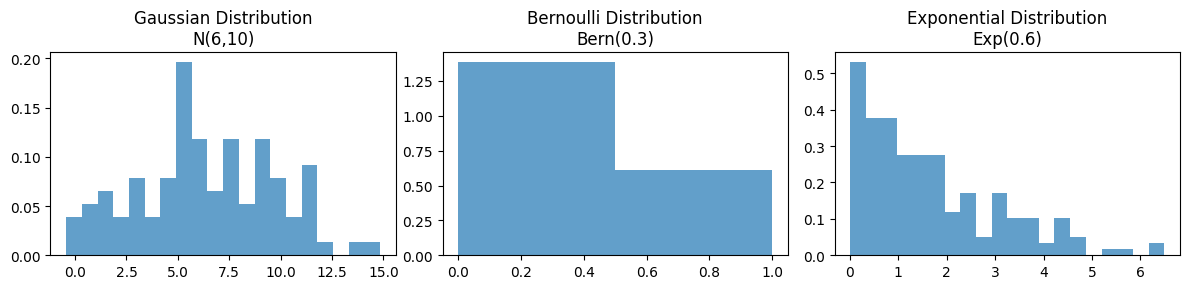

In [10]:
plt.figure(figsize=(12, 3))

# Plot Gaussian distribution
plt.subplot(131)
plt.hist(gaussian_samples, bins=20, density=True, alpha=0.7)
plt.title('Gaussian Distribution\nN(6,10)')

# Plot Bernoulli distribution
plt.subplot(132)
plt.hist(bernoulli_samples, bins=2, density=True, alpha=0.7)
plt.title('Bernoulli Distribution\nBern(0.3)')

# Plot Exponential distribution
plt.subplot(133)
plt.hist(exponential_samples, bins=20, density=True, alpha=0.7)
plt.title('Exponential Distribution\nExp(0.6)')

plt.tight_layout()
plt.show()

**6.3 Maximum Likelihood Estimation**

1. Gaussian Distribution N(μ, σ²)
- PDF: $$f(x|\mu,\sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}}\exp(-\frac{(x-\mu)^2}{2\sigma^2})$$
- MLE Solutions:
 $$\hat{\mu}_{MLE} = \frac{1}{n}\sum_{i=1}^n x_i$$
 $$\hat{\sigma}^2_{MLE} = \frac{1}{n}\sum_{i=1}^n(x_i-\hat{\mu}_{MLE})^2$$

In [11]:
gaussian_mean_mle = np.mean(gaussian_samples)  # MLE for mean
gaussian_var_mle = np.mean((gaussian_samples - gaussian_mean_mle)**2)  # MLE for variance

print("Gaussian Distribution MLE Results:")
print(f"Mean μ̂ = {gaussian_mean_mle:.4f} (True value: 6)")
print(f"Variance σ̂² = {gaussian_var_mle:.4f} (True value: 10)")

Gaussian Distribution MLE Results:
Mean μ̂ = 6.3792 (True value: 6)
Variance σ̂² = 11.1468 (True value: 10)


2. Bernoulli Distribution Bern(p)
- PMF: $$f(x|p) = p^x(1-p)^{1-x}, x\in\{0,1\}$$
- MLE Solution: $$\hat{p}_{MLE} = \frac{1}{n}\sum_{i=1}^n x_i$$

In [12]:
bernoulli_p_mle = np.mean(bernoulli_samples)

print("\nBernoulli Distribution MLE Results:")
print(f"Parameter p̂ = {bernoulli_p_mle:.4f} (True value: 0.3)")


Bernoulli Distribution MLE Results:
Parameter p̂ = 0.3067 (True value: 0.3)


3. Exponential Distribution Exp(λ)
- PDF: $$f(x|\lambda) = \lambda e^{-\lambda x}, x\geq 0$$
- MLE Solution: $$\hat{\lambda}_{MLE} = \frac{1}{\bar{x}} = \frac{n}{\sum_{i=1}^n x_i}$$

In [13]:
exponential_lambda_mle = 1/np.mean(exponential_samples)

print("\nExponential Distribution MLE Results:")
print(f"Parameter λ̂ = {exponential_lambda_mle:.4f} (True value: 0.6)")


Exponential Distribution MLE Results:
Parameter λ̂ = 0.6046 (True value: 0.6)


**6.4 Plot**

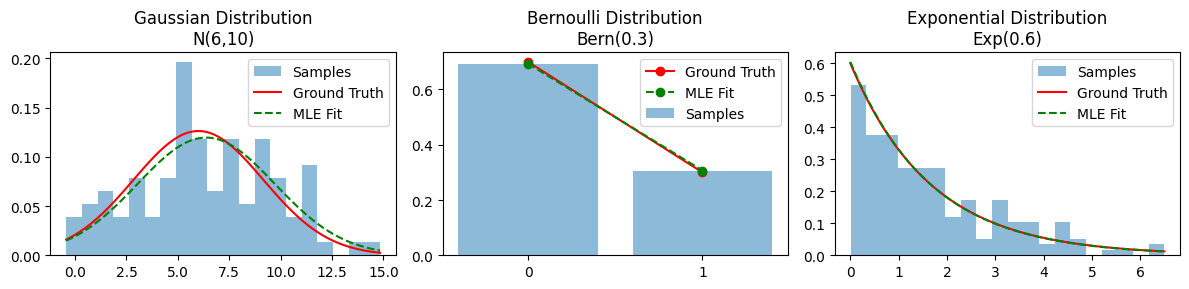

In [14]:
# Create plots
plt.figure(figsize=(12, 3))

# 1. Plot Gaussian Distribution
plt.subplot(131)
# Plot histogram of samples
plt.hist(gaussian_samples, bins=20, density=True, alpha=0.5, label='Samples')
# Create x points for plotting distributions
x_gaussian = np.linspace(min(gaussian_samples), max(gaussian_samples), 100)
# Plot ground truth distribution
plt.plot(x_gaussian, stats.norm.pdf(x_gaussian, 6, np.sqrt(10)), 
         'r-', label='Ground Truth')
# Plot MLE distribution
plt.plot(x_gaussian, stats.norm.pdf(x_gaussian, gaussian_mean_mle, np.sqrt(gaussian_var_mle)), 
         'g--', label='MLE Fit')
plt.title('Gaussian Distribution\nN(6,10)')
plt.legend()

# 2. Plot Bernoulli Distribution
plt.subplot(132)
# Plot sample proportions
plt.bar([0,1], [1-bernoulli_p_mle, bernoulli_p_mle], alpha=0.5, label='Samples')
# Plot ground truth probabilities
plt.plot([0,1], [0.7, 0.3], 'ro-', label='Ground Truth')
# Plot MLE probabilities
plt.plot([0,1], [1-bernoulli_p_mle, bernoulli_p_mle], 'go--', label='MLE Fit')
plt.title('Bernoulli Distribution\nBern(0.3)')
plt.xticks([0,1])
plt.legend()

# 3. Plot Exponential Distribution
plt.subplot(133)
# Plot histogram of samples
plt.hist(exponential_samples, bins=20, density=True, alpha=0.5, label='Samples')
# Create x points for plotting distributions
x_exp = np.linspace(0, max(exponential_samples), 100)
# Plot ground truth distribution
plt.plot(x_exp, stats.expon.pdf(x_exp, scale=1/0.6), 
         'r-', label='Ground Truth')
# Plot MLE distribution
plt.plot(x_exp, stats.expon.pdf(x_exp, scale=1/exponential_lambda_mle), 
         'g--', label='MLE Fit')
plt.title('Exponential Distribution\nExp(0.6)')
plt.legend()

plt.tight_layout()
plt.show()

**6.5 Changing sample size**

In [15]:
from ipywidgets import interactive, widgets
import ipywidgets as widgets

ModuleNotFoundError: No module named 'ipywidgets'

In [ ]:
class DistributionSampler:
    def __init__(self):
        self.reset_seed()
        
    def reset_seed(self):
        np.random.seed(42)
        
    def get_gaussian_samples(self, n):
        self.reset_seed()
        return np.random.normal(loc=6, scale=np.sqrt(10), size=n)
    
    def get_bernoulli_samples(self, n):
        self.reset_seed()
        return np.random.binomial(n=1, p=0.3, size=n)
    
    def get_exponential_samples(self, n):
        self.reset_seed()
        return np.random.exponential(scale=1/0.6, size=n)

sampler = DistributionSampler()

def plot_distributions(n_gaussian=100, n_bernoulli=150, n_exponential=180):
    # Generate samples and calculate MLEs
    # 1. Gaussian
    gaussian_samples = sampler.get_gaussian_samples(n_gaussian)
    gaussian_mean_mle = np.mean(gaussian_samples)
    gaussian_var_mle = np.mean((gaussian_samples - gaussian_mean_mle)**2)
    
    # 2. Bernoulli
    bernoulli_samples = sampler.get_bernoulli_samples(n_bernoulli)
    bernoulli_p_mle = np.mean(bernoulli_samples)
    
    # 3. Exponential
    exponential_samples = sampler.get_exponential_samples(n_exponential)
    exponential_lambda_mle = 1/np.mean(exponential_samples)
    
    # Create plots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 3))
    
    # 1. Gaussian Plot
    ax1.hist(gaussian_samples, bins=20, density=True, alpha=0.5, label='Samples')
    x_gaussian = np.linspace(min(gaussian_samples), max(gaussian_samples), 100)
    ax1.plot(x_gaussian, stats.norm.pdf(x_gaussian, 6, np.sqrt(10)), 
             'r-', label='Ground Truth')
    ax1.plot(x_gaussian, stats.norm.pdf(x_gaussian, gaussian_mean_mle, np.sqrt(gaussian_var_mle)), 
             'g--', label='MLE Fit')
    ax1.set_title(f'Gaussian N(6,10)\nMLE: μ={gaussian_mean_mle:.2f}, σ²={gaussian_var_mle:.2f}')
    ax1.legend()
    
    # 2. Bernoulli Plot
    ax2.bar([0,1], [1-bernoulli_p_mle, bernoulli_p_mle], alpha=0.5, label='Samples')
    ax2.plot([0,1], [0.7, 0.3], 'ro-', label='Ground Truth')
    ax2.plot([0,1], [1-bernoulli_p_mle, bernoulli_p_mle], 'go--', label='MLE Fit')
    ax2.set_title(f'Bernoulli Bern(0.3)\nMLE: p={bernoulli_p_mle:.3f}')
    ax2.set_xticks([0,1])
    ax2.legend()
    
    # 3. Exponential Plot
    ax3.hist(exponential_samples, bins=20, density=True, alpha=0.5, label='Samples')
    x_exp = np.linspace(0, max(exponential_samples), 100)
    ax3.plot(x_exp, stats.expon.pdf(x_exp, scale=1/0.6), 
             'r-', label='Ground Truth')
    ax3.plot(x_exp, stats.expon.pdf(x_exp, scale=1/exponential_lambda_mle), 
             'g--', label='MLE Fit')
    ax3.set_title(f'Exponential Exp(0.6)\nMLE: λ={exponential_lambda_mle:.3f}')
    ax3.legend()
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Create interactive widgets
interactive_plot = widgets.interactive(
    plot_distributions,
    n_gaussian=widgets.IntSlider(min=10, max=1000, step=10, value=100, description='Gaussian n:'),
    n_bernoulli=widgets.IntSlider(min=10, max=1000, step=10, value=150, description='Bernoulli n:'),
    n_exponential=widgets.IntSlider(min=10, max=1000, step=10, value=180, description='Exponential n:')
)

# Display the interactive plot
display(interactive_plot)

NameError: name 'widgets' is not defined